**Аттестационное задание №2: Анализ данных RFSD**

Данные
https://github.com/irlcode/RFSD


Проанализируйте данные с помощью Pandas или Polars.

ВАЖНО: Перед началом анализа сократите количество колонок до 20 и количество строк до 1000. Также, можете использовать streaming, чтобы не скачивать сразу весь датасет.

In [190]:
!pip install -q seaborn datasets

# Импортируем все необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Настройка стиля графиков: белый фон с сеткой
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки загружены.")

Библиотеки загружены.


**0. Подготовка данных**

In [191]:
# RFSD хранится на Hugging Face в формате parquet с разбивкой по годам.
# Загружаем только один год (2023), т.к весь дата сет слишком большой.

dataset_stream = load_dataset(
    "irlspbru/RFSD",
    data_files="RFSD/year=2023/*.parquet",  # указываем конкретный год
    split="train",                          # split обязателен для streaming
    streaming=True                            # ключевой параметр
)

print(f"Тип загруженного объекта: {type(dataset_stream)}")
print(f"Поддерживает ли to_pandas(): {hasattr(dataset_stream, 'to_pandas')}")

Тип загруженного объекта: <class 'datasets.iterable_dataset.IterableDataset'>
Поддерживает ли to_pandas(): True


In [192]:
# Метод take(1000) возвращает новый IterableDataset ровно из 1000 элементов.
# При этом реально скачиваются только эти 1000 строк — не весь год.

N_ROWS = 1000
limited_stream = dataset_stream.take(N_ROWS)

print(f"Создан поток, ограниченный {N_ROWS} строками.")
print("Данные будут загружены по мере итерации.")

Создан поток, ограниченный 1000 строками.
Данные будут загружены по мере итерации.


In [193]:
# Отбор 20 наиболее информативных финансовых показателей.
# Принцип отбора: покрыть все четыре формы отчётности (баланс, ОПУ, ОДДС, отчёт об изменениях капитала) + идентификаторы.

selected_columns = [
    # Идентификаторы
    'inn',              # ИНН компании (уникальный идентификатор)
    'region',           # Регион регистрации
    'okved',            # Основной вид деятельности (ОКВЭД)

    # Баланс
    'line_1100',        # Внеоборотные активы (итог раздела I)
    'line_1110',        # Нематериальные активы
    'line_1150',        # Основные средства
    'line_1200',        # Оборотные активы (итог раздела II)
    'line_1230',        # Дебиторская задолженность
    'line_1250',        # Денежные средства и эквиваленты
    'line_1300',        # Капитал и резервы (итог раздела III)
    'line_1400',        # Долгосрочные обязательства (итог раздела IV)
    'line_1500',        # Краткосрочные обязательства (итог раздела V)
    'line_1600',        # Валюта баланса (актив, итог)
    'line_1700',        # Валюта баланса (пассив, итог)

    # Отчёт о прибылях и убытках (P&L)
    'line_2110',        # Выручка
    'line_2120',        # Себестоимость продаж
    'line_2100',        # Валовая прибыль (убыток)
    'line_2200',        # Прибыль (убыток) от продаж
    'line_2400',        # Чистая прибыль (убыток)

    # Отчёт о движении денежных средств (CF)
    'line_4100',        # Чистый денежный поток от текущих операций
]

print(f"Определено {len(selected_columns)} колонок для анализа.")

Определено 20 колонок для анализа.


In [194]:
# Проходим по потоку, оставляя только нужные колонки.
# В память попадает ровно 1000 строк × 20 колонок.

rows = []
for i, row in enumerate(limited_stream):
    # row — это словарь {имя_колонки: значение}
    # Оставляем только те колонки, которые есть в selected_columns
    filtered_row = {col: row[col] for col in selected_columns if col in row}
    rows.append(filtered_row)

    # Прогресс каждые 200 записей — чтобы видеть, что процесс идёт
    if (i + 1) % 200 == 0:
        print(f"  Обработано строк: {i + 1}")

# Создаём Pandas DataFrame из собранных строк
df_sample = pd.DataFrame(rows)

print(f"\nГотово. Итоговый размер выборки: {df_sample.shape[0]} строк, {df_sample.shape[1]} колонок")
print(f"Названия колонок: {list(df_sample.columns[:])}")

  Обработано строк: 200
  Обработано строк: 400
  Обработано строк: 600
  Обработано строк: 800
  Обработано строк: 1000

Готово. Итоговый размер выборки: 1000 строк, 20 колонок
Названия колонок: ['inn', 'region', 'okved', 'line_1100', 'line_1110', 'line_1150', 'line_1200', 'line_1230', 'line_1250', 'line_1300', 'line_1400', 'line_1500', 'line_1600', 'line_1700', 'line_2110', 'line_2120', 'line_2100', 'line_2200', 'line_2400', 'line_4100']


In [195]:
# Первичная очистка данных
# Проверяем типы данных
print("Типы данных:")
print(df_sample.dtypes)
print()

# Проверяем пропуски
print("Пропуски по колонкам:")
missing = df_sample.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0] if (missing > 0).any() else "Пропусков нет.")

Типы данных:
inn           object
region        object
okved         object
line_1100    float64
line_1110    float64
line_1150    float64
line_1200    float64
line_1230    float64
line_1250    float64
line_1300    float64
line_1400    float64
line_1500    float64
line_1600    float64
line_1700    float64
line_2110    float64
line_2120    float64
line_2100    float64
line_2200    float64
line_2400    float64
line_4100    float64
dtype: object

Пропуски по колонкам:
line_1110    955
line_4100    925
line_2100    745
line_1400    687
line_1150    641
line_1100    577
line_2120    372
line_2200    361
line_2110    359
line_2400    314
line_1230    306
line_1500    295
line_1250    270
line_1300    253
line_1200    214
line_1600    174
line_1700    174
dtype: int64


In [196]:
# Приведение типов и заполнение пропусков

# Определяем список числовых колонок (без идентификаторов)
numeric_cols = [c for c in selected_columns
                if c not in ['inn', 'region', 'okved']
                and c in df_sample.columns]

# Приводим числовые колонки к типу float
# errors='coerce' — если встретится нечисловое значение, оно станет NaN
for col in numeric_cols:
    df_sample[col] = pd.to_numeric(df_sample[col], errors='coerce')

# Заполняем пропуски в числовых колонках нулями
# В бухгалтерской отчётности пропуск часто означает, что статьи просто нет
df_sample[numeric_cols] = df_sample[numeric_cols].fillna(0)

# Заменяем бесконечности на NaN, затем на 0
# (бесконечности могут появиться при делении в исходных данных)
df_sample[numeric_cols] = (df_sample[numeric_cols]
                            .replace([np.inf, -np.inf], np.nan)
                            .fillna(0))

print("После очистки:")
print(f"Пропусков всего: {df_sample.isnull().sum().sum()}")
print(f"Размер: {df_sample.shape}")
print(f"\nТипы данных после приведения:")
print(df_sample[numeric_cols].dtypes.value_counts())

После очистки:
Пропусков всего: 0
Размер: (1000, 20)

Типы данных после приведения:
float64    17
Name: count, dtype: int64


**1. Выведите описательную статистику для датасета**

In [197]:
# Выбираем только числовые колонки для статистики
# (inn, region, okved — это категориальные коды, их среднее не имеет смысла)
stat_cols = [c for c in numeric_cols if c in df_sample.columns]

desc_stats = df_sample[stat_cols].describe().T

# Добавляем дополнительные метрики: медиана, асимметрия, эксцесс
desc_stats['median'] = df_sample[stat_cols].median()
desc_stats['skewness'] = df_sample[stat_cols].skew()
desc_stats['kurtosis'] = df_sample[stat_cols].kurtosis()

# Округляем для читаемости
desc_stats = desc_stats.round(2)

print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("=" * 90)
print(desc_stats[['count', 'mean', 'std', 'min', 'median', 'max', 'skewness']].to_string())

ОПИСАТЕЛЬНАЯ СТАТИСТИКА
            count       mean         std          min  median          max  skewness
line_1100  1000.0   88740.74  1434616.26          0.0     0.0   43092170.0     27.53
line_1110  1000.0      18.30      288.79          0.0     0.0       7858.0     22.14
line_1150  1000.0   55658.65   918693.77          0.0     0.0   27924620.0     28.35
line_1200  1000.0  142779.67  1662417.36          0.0   623.5   38360474.0     18.49
line_1230  1000.0   86035.54  1167701.53          0.0   102.5   31445705.0     22.27
line_1250  1000.0    7679.97    92323.42      -1255.0    25.0    2218132.0     20.54
line_1300  1000.0   67151.15   756208.27   -3293712.0    51.5   16083322.0     14.89
line_1400  1000.0   49329.05   863776.05        -16.0     0.0   26551213.0     29.17
line_1500  1000.0  114947.27  1669679.17          0.0   121.0   46355797.0     23.73
line_1600  1000.0  231520.41  2911503.26          0.0   853.5   81452644.0     23.42
line_1700  1000.0  231479.95  2911505.79 

**Найдите в данных минимум три интересные детали – закономерности, неожиданные связи или аномалии:**
1. У ключевх показателей прибыли медиана равна нулю. Что это значит, что у половины компаний в выборке валовая прибыль, прибыль от продаж, чистая прибыль и денежный поток одновременно равны нулю. Такой структуры в нормальных финансовых данных не бывает, она характерна для выборок, где доминируют не типичные прибыльные фирмы, а микробизнес с нулевой отчётностью или «спящие» юрлица.
2. line_2120 - Себестоимость продаж имеет мах=0, мин= -115328730 и медиана=-477,5
Все значения себестоимость продаж - ноль и отрицательные. В бух учете себестоимость - расход, но в отчетности она отражается как положительное число. Здесть себестоимость хранится со знаком "-". Это может может привести к аномалиям.
3.  line_2200 - Прибыль (убыток) от продаж имеет среднее=-8801,96, медиана=0, лев.ассиметрию=-30,68
Это указывает на то что компания теряе деньги на основной деятельности (средняя прибыль - отрицательна), такой результат редко встречается в "нормальных" финансовых выборках, обычно среднее - полочительно и убыточных компаний меньше половины. Если медиана=0, а среднее отрицательно, то можно говорить о том, что в выборке крупные "плохие" компании смещены вниз. В классическом варианте наоборот несколько крупных компаний тянут среднее вверх

**2. Постройте гистограммы для трех колонок, которые, на ваш взгляд, могут содержать полезную информацию. Выясните, есть ли в этих колонках выбросы и аномалии (значения, которые сильно отличаются от остальных значений или кажутся странными/некорректными).**

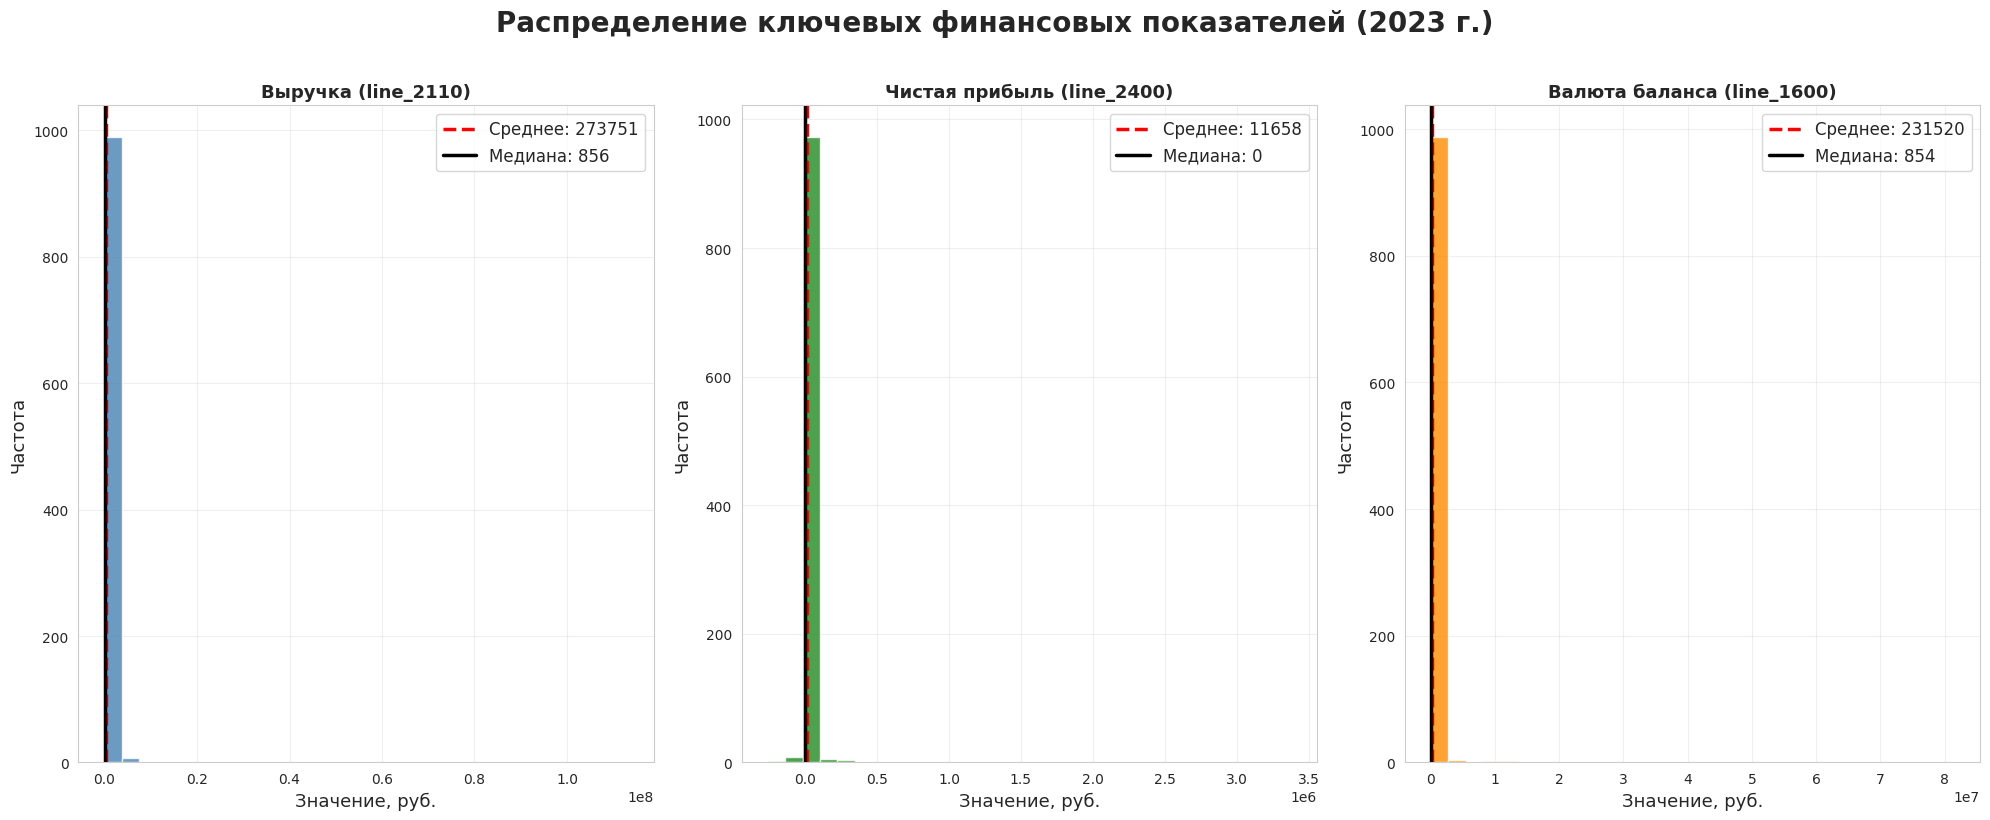

In [198]:
# Выбираем три колонки, которые потенциально интересны:
# 1. line_2110 (Выручка) — масштаб бизнеса
# 2. line_2400 (Чистая прибыль) — финансовый результат
# 3. line_1600 (Валюта баланса) — размер компании

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

hist_cols = [
    ('line_2110', 'Выручка (line_2110)', 'steelblue'),
    ('line_2400', 'Чистая прибыль (line_2400)', 'forestgreen'),
    ('line_1600', 'Валюта баланса (line_1600)', 'darkorange'),
]

for ax, (col, title, color) in zip(axes, hist_cols):
    if col not in df_sample.columns:
        ax.set_visible(False)
        continue

    data = df_sample[col]

    # Гистограмма с 30 бинами
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Значение, руб.', fontsize=13)
    ax.set_ylabel('Частота', fontsize=13)
    ax.grid(True, alpha=0.3)

    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2.5,
               label=f'Среднее: {data.mean():.0f}')
    ax.axvline(data.median(), color='black', linestyle='-', linewidth=2.5,
               label=f'Медиана: {data.median():.0f}')
    ax.legend(fontsize=12)

plt.suptitle('Распределение ключевых финансовых показателей (2023 г.)',
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация гистограмм:**

- Все три распределения (выручка, чистая прибыль, валюта баланса) имеют ярко выраженную правостороннюю асимметрию: основная масса наблюдений сосредоточена вблизи нуля, но есть длинный «хвост» из крупных компаний.
- Медиана чистой прибыли равна нулю — это означает, что более половины компаний в выборке имеют нулевую чистую прибыль. Это нетипично для «здоровой» экономики и говорит о доминировании микробизнеса с нулевой отчётностью или «спящих» юрлиц.
- Разрыв между средним и медианой (в 270–320 раз для выручки и валюты баланса) — классический признак закона Парето.
- Выбросы: до 24.5% значений в каждой колонке выходят за пределы 1.5×IQR. Это реальные крупные компании, а не ошибки данных.
- Из-за сильной асимметрии гистограммы плохо читаются — для наглядности стоит применять лог-шкалу (см. доп. ячейку ниже).

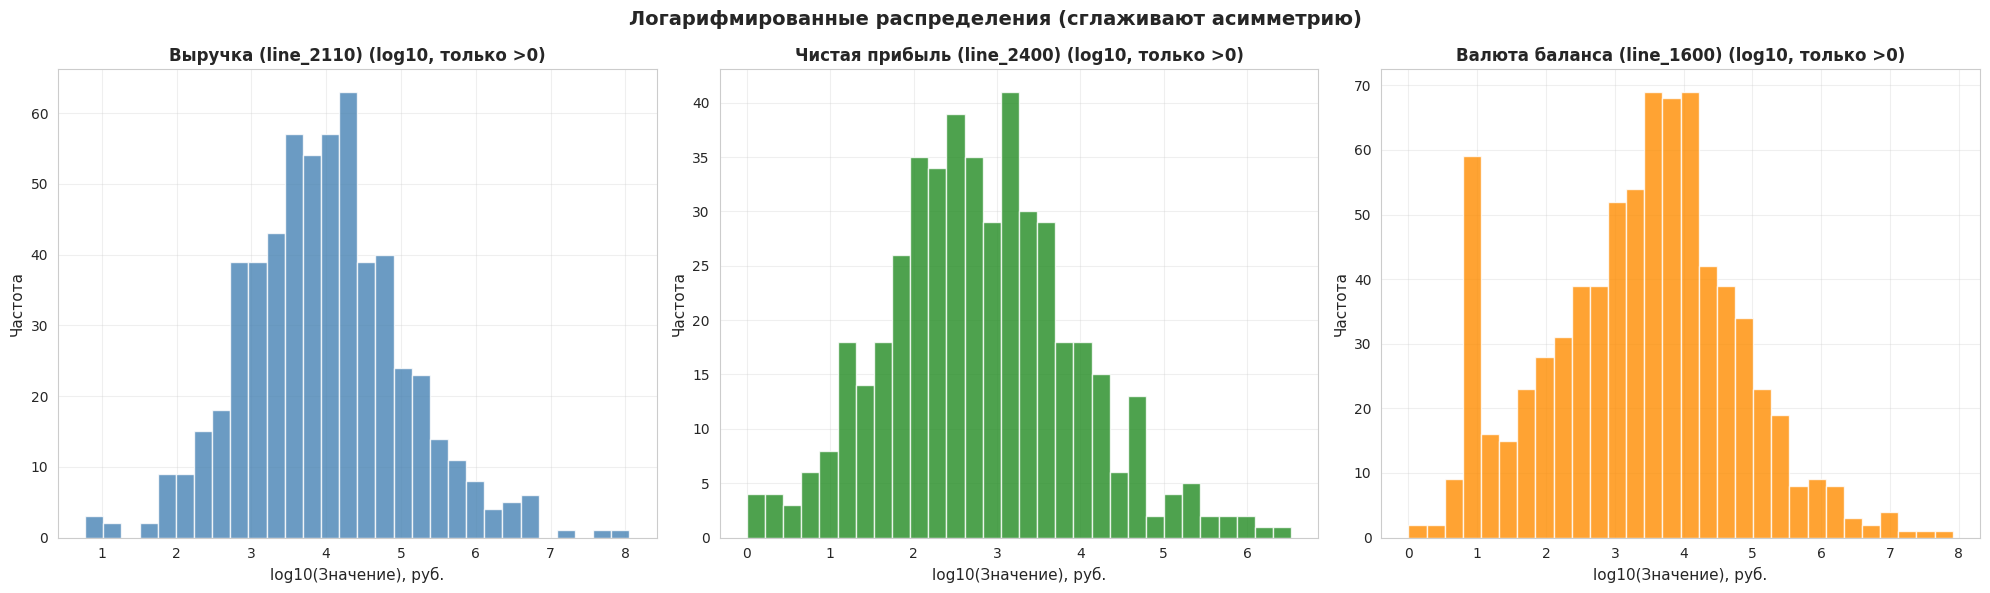

In [199]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (col, title, color) in zip(axes, hist_cols):
    data = df_sample[col][df_sample[col] > 0]  # только положительные
    ax.hist(np.log10(data), bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{title} (log10, только >0)', fontsize=12, fontweight='bold')
    ax.set_xlabel('log10(Значение), руб.', fontsize=11)
    ax.set_ylabel('Частота', fontsize=11)
    ax.grid(True, alpha=0.3)
plt.suptitle('Логарифмированные распределения (сглаживают асимметрию)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**3. Вычислите и визуализируйте матрицу корреляции между всеми 20 колонками. Между какими колонками имеется высокая корреляция? Что означает эта высокая корреляция и в чем может быть ее причина?**

Колонок для корреляционного анализа: 20


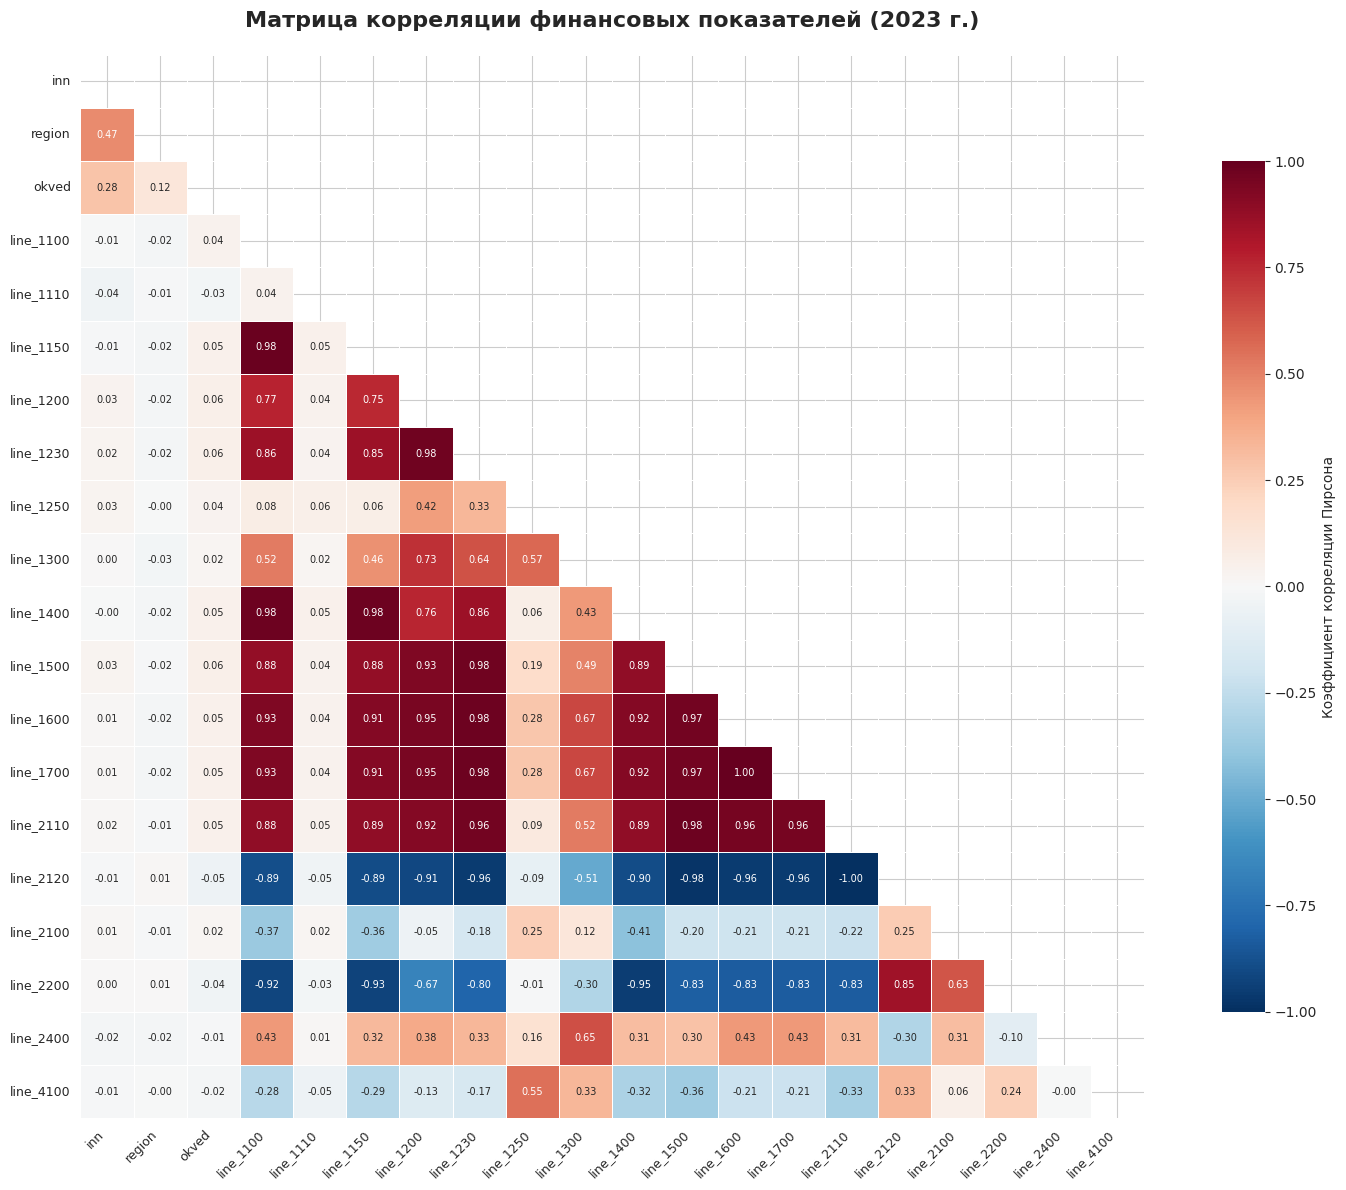


ТОП-10 САМЫХ СИЛЬНЫХ КОРРЕЛЯЦИЙ:
line_1150       <-> line_1100       : 0.985
line_1100       <-> line_1150       : 0.985
line_1400       <-> line_1100       : 0.983
line_1100       <-> line_1400       : 0.983
line_1230       <-> line_1600       : 0.980
line_1600       <-> line_1230       : 0.980
line_1700       <-> line_1230       : 0.980
line_1230       <-> line_1700       : 0.980
line_2110       <-> line_1500       : 0.978
line_1500       <-> line_2110       : 0.978


In [200]:
# По заданию нужна матрица корреляции между всеми 20 колонками.
# Категориальные коды (inn, region, okved) не имеют числового смысла,
# поэтому кодируем их через pd.factorize — тогда все 20 колонок будут числовыми.

df_encoded = df_sample.copy()
for cat_col in ['inn', 'region', 'okved']:
    if cat_col in df_encoded.columns:
        df_encoded[cat_col] = pd.factorize(df_encoded[cat_col])[0]

corr_cols = list(df_encoded.columns)
print(f"Колонок для корреляционного анализа: {len(corr_cols)}")

# Вычисляем матрицу корреляции Пирсона по всем 20 колонкам
corr_matrix = df_encoded[corr_cols].corr(method='pearson')

# Визуализация: heatmap с аннотациями
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # скрываем верхний треугольник

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # показываем значения
    fmt='.2f',            # два знака после запятой
    cmap='RdBu_r',        # красно-синяя палитра (обратная)
    center=0,             # белый цвет = 0
    vmin=-1, vmax=1,      # границы от -1 до 1
    square=True,          # квадратные ячейки
    linewidths=0.5,       # линии между ячейками
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции Пирсона'},
    annot_kws={'size': 7} # размер подписей
)

plt.title('Матрица корреляции финансовых показателей (2023 г.)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Топ-10 самых сильных корреляций (по модулю)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # исключаем корреляцию с самим собой

# Явно исключаем бухгалтерское тождество: актив = пассив.
# Эта пара даёт r = 1.0 по определению и не является интересной находкой.
corr_pairs = corr_pairs[
    ~corr_pairs.index.isin([
        ('line_1600', 'line_1700'),
        ('line_1700', 'line_1600'),
    ])
]
top_corr = corr_pairs.head(10)

print("\nТОП-10 САМЫХ СИЛЬНЫХ КОРРЕЛЯЦИЙ:")
print("=" * 60)
for (col1, col2), val in top_corr.items():
    print(f"{col1:15s} <-> {col2:15s} : {val:.3f}")

**Интерпретация матрицы корреляции:**

- Большинство балансовых и P&L-показателей сильно коррелируют между собой (r > 0.9). Это объясняется **масштабным фактором**: крупные компании одновременно имеют большие активы, выручку, обязательства и капитал.
- line_1600 и line_1700 (актив и пассив) = 1.0 — это бухгалтерское тождество, поэтому не включаем в топ.
- Самая сильная содержательная связь: line_1150 и line_1100 (r = 0.985) — основные средства ожидаемо формируют основную часть внеоборотных активов.
- **Ограничение:** inn, region, okved были закодированы через *factorize* только чтобы получить 20 числовых колонок. Корреляции по ним статистически бессмысленны (это категориальные коды, а не порядковые шкалы). Их следует игнорировать при интерпретации.
- **Практический вывод:** при построении регрессий на этих данных неизбежна мультиколлинеарность — нужно либо использовать PCA, либо оставить одну из группы сильно скоррелированных переменных.

**4. Постройте диаграмму рассеивания (scatter plot) между коррелирующими колонками.**

Наиболее коррелирующая пара: line_1150 и line_1100
Коэффициент корреляции: 0.985


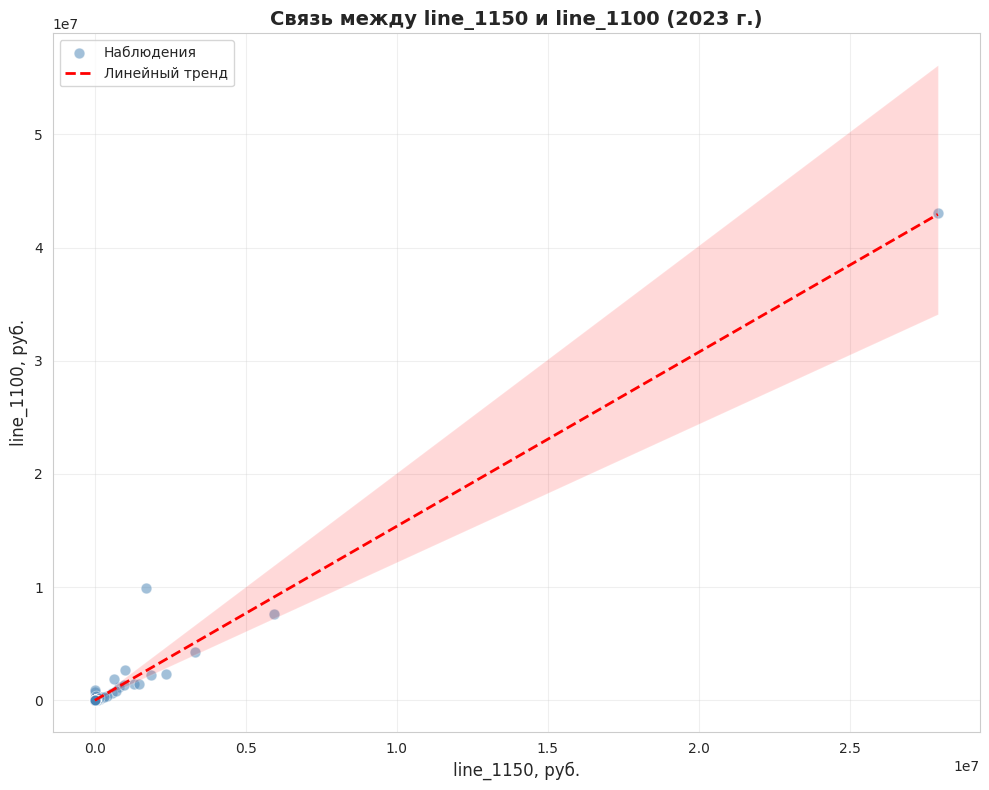

In [201]:
# Находим пару с самой высокой корреляцией
top_pair = top_corr.index[0]
col_x, col_y = top_pair[0], top_pair[1]

print(f"Наиболее коррелирующая пара: {col_x} и {col_y}")
print(f"Коэффициент корреляции: {corr_matrix.loc[col_x, col_y]:.3f}")

# Создаём scatter plot с линией регрессии
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=df_sample,
    x=col_x,
    y=col_y,
    alpha=0.5,        # полупрозрачные точки
    color='steelblue',
    edgecolor='white',
    s=60,              # размер точек
    label='Наблюдения'
)

# Линия регрессии (тренд)
sns.regplot(
    data=df_sample,
    x=col_x,
    y=col_y,
    scatter=False,    # не рисуем точки повторно
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    label='Линейный тренд'
)

plt.title(f'Связь между {col_x} и {col_y} (2023 г.)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'{col_x}, руб.', fontsize=12)
plt.ylabel(f'{col_y}, руб.', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Интерпретация диаграммы рассеивания:

- Между основными средствами (line_1150) и внеоборотными активами (line_1100) наблюдается почти линейная зависимость — что логично, т.к. основные средства обычно составляют основную долю внеоборотных активов.
- **Важное замечание:** у обеих колонок медиана равна нулю. Это означает, что >50% точек лежат в начале координат. Высокий r = 0.985 формируется за счёт нескольких десятков крупных компаний в правой части графика.
- Точки плотно лежат на линии тренда без заметных отклонений — значит, среди крупных компаний нет аномалий, где основные средства резко превышали бы внеоборотные активы (и наоборот).
- Для более наглядной картины ниже рассмотрена пара без «нулевых медиан»,  line_2110 и line_1600 (выручка и валюта баланса).

Дополнительная пара: line_2110 и line_1600
Коэффициент корреляции: 0.960
Медиана line_2110: 856
Медиана line_1600: 854


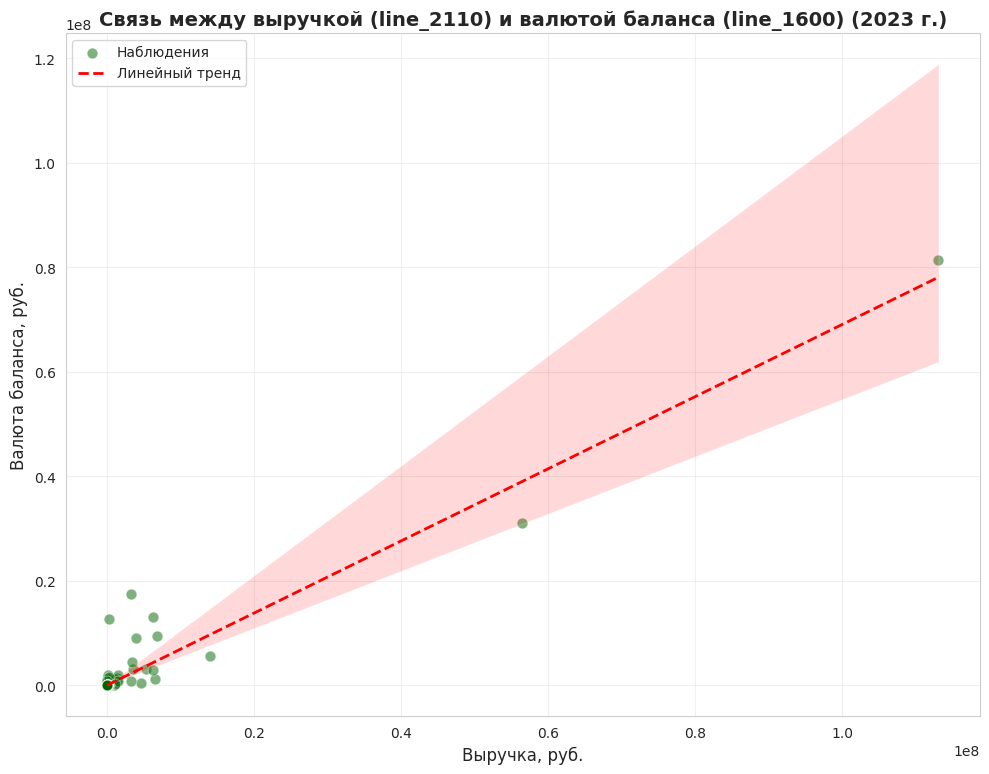

In [202]:
# Дополнительный scatter plot для пары с ненулевыми медианами:
# Выручка (line_2110) и валюта баланса (line_1600)

col_x2, col_y2 = 'line_2110', 'line_1600'

print(f"Дополнительная пара: {col_x2} и {col_y2}")
print(f"Коэффициент корреляции: {corr_matrix.loc[col_x2, col_y2]:.3f}")
print(f"Медиана {col_x2}: {df_sample[col_x2].median():,.0f}")
print(f"Медиана {col_y2}: {df_sample[col_y2].median():,.0f}")

plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=df_sample,
    x=col_x2,
    y=col_y2,
    alpha=0.5,
    color='darkgreen',
    edgecolor='white',
    s=60,
    label='Наблюдения'
)

# Линия регрессии
sns.regplot(
    data=df_sample,
    x=col_x2,
    y=col_y2,
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    label='Линейный тренд'
)

plt.title(f'Связь между выручкой ({col_x2}) и валютой баланса ({col_y2}) (2023 г.)',
          fontsize=14, fontweight='bold')
plt.xlabel('Выручка, руб.', fontsize=12)
plt.ylabel('Валюта баланса, руб.', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

При анализе корреляций финансовых показателей важно выбирать пары с ненулевыми медианами, чтобы избежать искажения картины из-за большого числа нулевых значений. Это позволяет более объективно оценить силу и характер связи.

На графике видна чёткая линейная зависимость: с ростом выручки увеличивается и валюта баланса. Это ожидаемо, так как крупные компании обычно имеют и больший масштаб бизнеса, и больший размер активов.

**5. Сделайте как минимум один вывод исходя из описательной статистики, гистограмм, матрицы корреляции, диаграммы рассеивания.**

In [203]:
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА")

# Вывод 1: Асимметрия распределения
print("-" * 40)
print("\n1. Асимметрия финансовых показателей")
for col, title, _ in hist_cols:
    if col not in df_sample.columns:
        continue
    mean_val = df_sample[col].mean()
    median_val = df_sample[col].median()
    ratio = mean_val / median_val if median_val != 0 else float('inf')
    print(f"{title}: среднее/медиана = {ratio:.1f}x")

print(""" Интерпретация: средние значения значительно превышают медианные для всех ключевых показателей. Это означает, что распределение
финансовых результатов сильно скошено вправо: несколько очень крупных компаний «тянут» среднее вверх, тогда как типичная
российская компания в выборке значительно меньше. Это классическая картина для финансовых данных — закон Парето в действии.""")

# Вывод 2: Корреляционная структура
print("-" * 40)
print("\n2. Высокая корреляция между финансовыми показателями")
high_corr = [(c1, c2, v) for (c1, c2), v in corr_pairs.items() if abs(v) > 0.7][:5]
for c1, c2, v in high_corr:
    print(f"  {c1} <-> {c2}: r = {v:.3f}")

print("""
Интерпретация: большинство финансовых показателей коррелируют друг с другом с коэффициентом >0.7. Причина — масштабный фактор:
крупные компании имеют и большую выручку, и больше активов, и больше обязательств. Это означает, что при построении моделей
(например, кредитного скоринга) нужно остерегаться мультиколлинеарности.""")

# Вывод 3: Наличие выбросов

def detect_outliers_iqr(series, title):
    """Выводит статистику выбросов по методу межквартильного размаха (IQR)."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]

    print(f"\n--- {title} ---")
    print(f"Q1 (25-й перцентиль): {q1:,.0f}")
    print(f"Q3 (75-й перцентиль): {q3:,.0f}")
    print(f"IQR: {iqr:,.0f}")
    print(f"Нижняя граница: {lower:,.0f}")
    print(f"Верхняя граница: {upper:,.0f}")
    print(f"Количество выбросов: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)")

print("-" * 40)
print("\n3. Наличие выбросов")
for col, title, _ in hist_cols:
    if col not in df_sample.columns:
        continue
    detect_outliers_iqr(df_sample[col], title)

print("""
Интерпретация: В каждой из трёх колонок обнаружены выбросы (см. значения выше). Это не ошибки
  данных, а реальные крупные компании.""")

# Общий вывод
print("\n" + "=" * 80)
print("ОБЩИЙ ВЫВОД:")
print("""Данные RFSD за 2023 год демонстрируют классические закономерности финансовой отчётности: сильную правостороннюю
асимметрию, высокую корреляцию между показателями масштаба и наличие значительного числа выбросов (крупных компаний).
Эти закономерности необходимо учитывать при построении любых аналитических моделей на основе этих данных.""")



ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА
----------------------------------------

1. Асимметрия финансовых показателей
Выручка (line_2110): среднее/медиана = 319.8x
Чистая прибыль (line_2400): среднее/медиана = infx
Валюта баланса (line_1600): среднее/медиана = 271.3x
 Интерпретация: средние значения значительно превышают медианные для всех ключевых показателей. Это означает, что распределение
финансовых результатов сильно скошено вправо: несколько очень крупных компаний «тянут» среднее вверх, тогда как типичная
российская компания в выборке значительно меньше. Это классическая картина для финансовых данных — закон Парето в действии.
----------------------------------------

2. Высокая корреляция между финансовыми показателями
  line_1150 <-> line_1100: r = 0.985
  line_1100 <-> line_1150: r = 0.985
  line_1400 <-> line_1100: r = 0.983
  line_1100 <-> line_1400: r = 0.983
  line_1230 <-> line_1600: r = 0.980

Интерпретация: большинство финансовых показателей коррелируют друг с другом с коэффицие